# Wine Quality Prediction Model Evaluation

---
embed-resources: true
echo: false
---

## Introduction

There are many factors that affect wine quality, even the smallest things such as the grape's growing condition. Traditionally, sommeliers have been entrusted with evaluating wines and suggesting their food pairings. They have to be trained extensively for many years in order to be able to assess wines based on their taste, aroma, and texture. However, as experts in the wine industry, you know firsthand that even top sommeliers can bring their own preferences into evaluations, and it takes a large investment in time and cost to develope said expertise.

Therefore, rather than solely relying on sensory expertise, we seek to create an **AI Sommelier** that blends human knowledge, modern chemistry, and artificial intelligence to deliver consistent and object assessments of wine quality. By looking at measurable and concrete attributes like acidity and alcohol content then connecting them to past ratings from sommeliers, our goal is to develop a model that preducts a wine's perceived quality reliably and at scale. 

This model uses extensive data on Portuguese "Vinho Verde" wines, incorporating both expert reviews and detailed lab measurements. By training our model on these data, we hope to automate the process of wine evaluation to uphold quality standards and optimize operation costs. 

## Methods

In [29]:
# basic imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# model imports
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neighbors import KNeighborsClassifier

# metric imports
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_absolute_error

# model selection imports
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# preprocessing imports
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

The model uses data from a foundational scientific study of Portuguese "Vinho Verde" wines tht has been adopted as a machine learning benchmark via the UC Irvine Machine Learning Repository. It combined lab and expert review data for both red and white wine samples.

### Data

In [2]:
# load data
wine_train = pd.read_parquet(
    "https://lab.cs307.org/wine/data/wine-train.parquet",
)
wine_test = pd.read_parquet(
    "https://lab.cs307.org/wine/data/wine-test.parquet",
)

#### Data Dictionary

- **`quality`**: `[int64]` the quality of the wine based on evaluation by a minimum of three sensory assessors (using blind tastes), which graded the wine in a scale that ranges from 0 (very bad) to 10 (excellent)

- **`color`**: `[object]` the (human perceivable) color of the wine, red or white

- **`fixed acidity`**:`[float64]` grams of tartaric acid per cubic decimeter

- **`volatile acidity`**: `[float64]` grams of acetic acid per cubic decimeter

- **`citric acid`**: `[float64]` grams of citric acid per cubic decimeter

- **`residual sugar`**: `[float64]` grams of residual sugar per cubic decimeter

- **`chlorides`**: `[float64]` grams of sodium chloride cubic decimeter

- **`free sulfur dioxide`**: `[float64]` milligrams of free sulfur dioxide per cubic decimeter

- **`total sulfur dioxide`**: `[float64]` milligrams of total sulfur dioxide per cubic decimeter

- **`density`**: `[float64]` the total density of the wine in grams per cubic centimeter

- **`pH`**: `[float64]` the acidity of the wine measured using [pH](https://en.m.wikipedia.org/wiki/PH)

- **`sulphates`**: `[float64]` grams of potassium sulphate cubic decimeter

- **`alcohol`**: `[float64]` percent [alcohol by volume](https://en.m.wikipedia.org/wiki/Alcohol_by_volume)

#### Summary Statistics

Using the data, the key statistics are as follow:

- Number of samples: 4157
- Number of features: 12

**Summary table for each numeric feature:**

In [11]:
features = wine_train.drop(columns=['quality','color'])
features.agg(['mean','std','min','max'])

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
mean,7.220579,0.342403,0.316478,5.430406,0.056358,30.600048,115.221915,0.994710,3.218454,0.531784,10.502847
std,1.295282,0.166465,0.145276,4.750618,0.035460,17.906396,56.581139,0.003004,0.159184,0.150914,1.189918
min,3.800000,0.080000,0.000000,0.600000,0.012000,1.000000,6.000000,0.987110,2.740000,0.230000,8.000000
max,15.900000,1.330000,1.230000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000


**Quality scores distribution for each wine color:**

In [ ]:

pd.DataFrame(wine_train.groupby('color')['quality'].agg(['mean','std','min','max']))

,mean,std,min,max
color,,,,
red,5.630579,0.800009,3,8
white,5.876611,0.882337,3,9


#### Exploratory Visualization

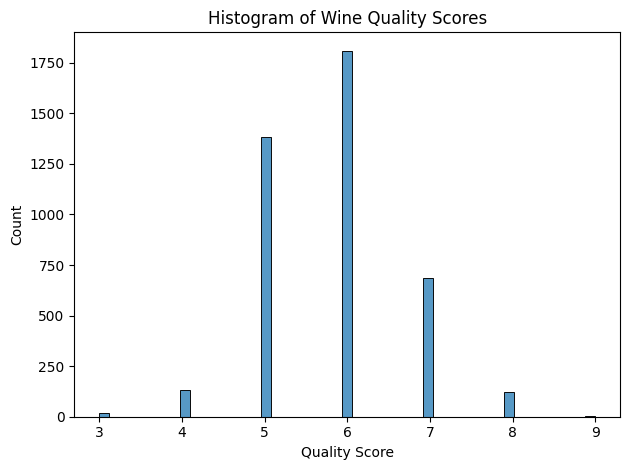

In [13]:
# exploratory visualization
df = pd.DataFrame(wine_train)
sns.histplot(df['quality'])
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.title('Histogram of Wine Quality Scores')
plt.tight_layout()

::: {.caption}

**Figure 1.** Histogram showing the distribution of wine quality scores in the training dataset. Most wine ratings are between 5 and 7, with the majority receiving a score of 6. Lower and higher scores are pretty rare. 

:::

### Models

A classification pipeline is constructed to predict wine quality ratings based on measured properties. The main steps taken are:

- **Preprocessing**: Missing values in numerical features were imputed using mean values and standardized to ensure uniform scale. Missing categorial feature of win color were filled with the most frequent value then one-hot encoded.

- **Model Selection**: After evaluation of various algorithms, a k-nearest neighbors classifier was selected for good performance on tabular data. 

- **Tuning**: Key parameters of the classifier such as the number of neighbors were optimized using grid search combined with cross-validation to maximize predictive accuracy, measured by mean absolute error. 

- **Pipeline**: All preprocessing steps and the estimator were integrated into a single `sklearn` pipline, ensuring consistency and reproducibility throughout model training and deployment. 

- **Evaluation**: The final model was trained on the provided training set and evaluated on the test set using mean absolute error, which quantifies that difference between predicted and actual quality scores. 

The data was partitioned into training sets and test sets. The test sets served as an unseen sample to evaluate the model's ability to predict wine quality score.

In [19]:
# create X and y for train
X_train = wine_train.drop("quality", axis=1)
y_train = wine_train["quality"]

# create X and y for test
X_test = wine_test.drop("quality", axis=1)
y_test = wine_test["quality"]

To evaluate the accuracy of the developed model, wine quality predictions were generated on the test dataset and measured by mean absolute error. A low mean absolute error on the test dataset indicates that the model can reliably estimate sommelier ratings and supports its potential for automating quality assessment.

In [ ]:
# train models

num_features = ['fixed acidity', 'volatile acidity','citric acid','residual sugar','chlorides','free sulfur dioxide','total sulfur dioxide','density','pH','sulphates','alcohol']
cat_features = ['color']

#preprocessing for num features 
numeric_transformer = Pipeline(
    [
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler())
    ]
)

#define preprocessing for categorical features
categorical_transformer = Pipeline(
    [
        ('imputer', SimpleImputer(strategy="most_frequent")),
        ('encoder', OneHotEncoder())
    ]
)

#create general preprocessor 
preprocessor = ColumnTransformer(
    [
        ('numeric', numeric_transformer, num_features),
        ('categorical', categorical_transformer, cat_features)
    ],
    remainder= 'drop',
)

#put everything tgt, build knn model 
knn = Pipeline(
    [
        ('preprocessor', preprocessor),
        ('classifier', KNeighborsClassifier()),
    ]
)

param_grid = {
    "classifier__n_neighbors": range(1,25),
    "classifier__p": [1, 2],
    "preprocessor__numeric__scaler": [None, StandardScaler()],
}
mod = GridSearchCV(
    knn,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
)

mod.fit(X_train, y_train)
# predict on the test data
y_test_pred = mod.predict(X_test)

# calculate and print the test accuracy
test_mae = mean_absolute_error(y_test, y_test_pred)

## Results

The model achieved a mean absolute error (MAE) of approximately **0.48** on the test data, indicating that its predicted quality ratings are on par with expert sommelier scores. This performance demonstrates the potential of the model to provide reliable, automated wine quality assessments in practical industry applications. 

In [26]:
# report model metrics
print(f"Test MAE: {test_mae}")

Test MAE: 0.47596153846153844


A **Confusion Matrix** for the test set is generate to visualize how closely the model's predictions align with the real scores, as well as the error across the scoring range. 

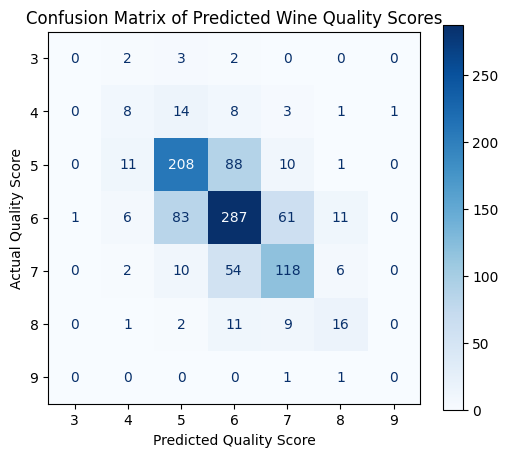

In [33]:
# summary figure

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    ax=ax,
    display_labels= sorted(set(y_test)),
    im_kw={"cmap": "Blues"}
)

ax.set_title('Confusion Matrix of Predicted Wine Quality Scores')
ax.set_xlabel("Predicted Quality Score")
ax.set_ylabel("Actual Quality Score")
ax.grid(False)
plt.show()

::: {.caption}

**Figure 2.** Confusion matrix comparing predicted wine quality scores to actual sommelier ratinga in the test set. The diagonal cells indicate correct predictions, while off-diagonal entries show misclassifications. A concentration on the diagonal demonstrates the model's accuracy, while off-diagonal patterns identify common prediction errors  

:::

## Discussion

#### Conclusion

Based on the model's performance and the specific scenario of automating wine evaluation, I believe that there is a strong potential in this approach, but I would not immediately deploy the current model in practice without furthere refinement and validation. The current model demonstrates that predicting wine quality from objectve measurements is feasible, but requires additional safeguards before replacing human experts in production workflows. 

#### Justification

While the model achieved a mean absolute error of approximately 0.48 on the test data, this metric should not be the only evaluation. Accuracy of the model does not convert into business readiness, especially in an industry where small differences in quality scores can have significant consequences on the companies and consumers. The model also showed systematic misclassifications for certain scores as seen in the confusion matric, indicating it may struggle to distinguish between similar quality levels. 

#### Risks

Deploying the current model could result in: 

- Overrated wines being selected for premium placement, damaging brand reputation if customers or human experts rte them lower. 

- Underrated wines being overlooked, potentially missing valuable opportunities in marketing or distribution. 

- Reduced trust in the AI system if sommeliers consistently disagree, leading to lower adoption and missed operational efficiencies. 

- Bias from historical ratings from the training data can skew the quality scores assessments. 

#### Improvements for use

Before deploying in the real-world, the model should:

- Collect more diverse training data, including multiple regions and expert panels to reduce bias. 

- Conduct extensive validation, inclusing blind side-by-side comparisons with human sommeliers and feedbck loops for continuous improvement. 

- Introduce uncertainty estimates to present predictions as a range to help users make informed decisions. 

- Develop periodic retraining and monitoring as wine production practices and consumer preferences evolve. 

In summary, the current model's deployment should be considered a staged process, involving further testing and ongoing refinement to ensure alignment with business goals and quality standards. 

